Revenue Forecasting Using Linear Regression on Financial Statements

In [1]:
import pandas as pd
import seaborn as sns 
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv("Financial Statements.csv")

In [3]:
df.head(5)

,Year,Company,Category,Market Cap(in B USD),Revenue,Gross Profit,Net Income,Earning Per Share,EBITDA,Share Holder Equity,...,Current Ratio,Debt/Equity Ratio,ROE,ROA,ROI,Net Profit Margin,Free Cash Flow per Share,Return on Tangible Equity,Number of Employees,Inflation Rate(in US)
0,2022,AAPL,IT,2066.94,394328.0,170782.0,99803.0,6.11,130541.0,50672.0,...,0.8794,2.3695,196.9589,28.2924,66.6994,25.3096,1.3146,196.9589,164000,8.0028
1,2021,AAPL,IT,2913.28,365817.0,152836.0,94680.0,5.61,120233.0,63090.0,...,1.0746,1.9768,150.0713,26.9742,54.9839,25.8818,1.3261,150.0713,154000,4.6979
2,2020,AAPL,IT,2255.97,274515.0,104956.0,57411.0,3.28,77344.0,65339.0,...,1.3636,1.7208,87.8664,17.7256,35.0054,20.9136,1.0183,87.8664,147000,1.2336
3,2019,AAPL,IT,1304.76,260174.0,98392.0,55256.0,2.97,76477.0,90488.0,...,1.5401,1.1940,61.0645,16.3230,30.3113,21.2381,-0.0388,61.0645,137000,1.8122
4,2018,AAPL,IT,748.54,265595.0,101839.0,59531.0,2.98,81801.0,107147.0,...,1.1329,1.0685,55.5601,16.2775,29.6348,22.4142,0.7414,55.5601,132000,2.4426


In [4]:
df.shape

(161, 23)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 23 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Year                                 161 non-null    int64  
 1   Company                              161 non-null    object 
 2   Category                             161 non-null    object 
 3   Market Cap(in B USD)                 160 non-null    float64
 4   Revenue                              161 non-null    float64
 5   Gross Profit                         161 non-null    float64
 6   Net Income                           161 non-null    float64
 7   Earning Per Share                    161 non-null    float64
 8   EBITDA                               161 non-null    float64
 9   Share Holder Equity                  161 non-null    float64
 10  Cash Flow from Operating             161 non-null    float64
 11  Cash Flow from Investing        

In [6]:
df['Company '].unique()

array(['AAPL', 'MSFT', 'GOOG', 'PYPL', 'AIG', 'PCG', 'SHLDQ', 'MCD',
       'BCS', 'NVDA', 'INTC', 'AMZN'], dtype=object)

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,161.0,2015.608696,4.049960,2009.0000,2012.0000,2016.0000,2019.0000,2.023000e+03
Market Cap(in B USD),160.0,337.604313,541.102812,0.0400,41.1550,113.1400,357.1075,2.913280e+03
Revenue,161.0,75862.600758,90786.895983,3326.4450,22820.4000,45992.0400,77849.0000,5.139830e+05
Gross Profit,161.0,37383.463124,41669.093697,1174.2690,10396.0000,19561.0000,47722.0000,2.251520e+05
Net Income,161.0,12276.607076,19417.421119,-12244.0000,844.0000,4757.8000,14136.0000,9.980300e+04
Earning Per Share,161.0,0.982886,8.874504,-90.4800,0.3400,1.7900,3.2400,1.498000e+01
EBITDA,161.0,20174.023974,26342.029803,-6860.0000,2310.0000,9958.0000,27765.0000,1.305410e+05
Share Holder Equity,161.0,57178.005273,54098.208311,-8210.3000,12353.0000,47791.0000,91570.7000,2.561440e+05
Cash Flow from Operating,161.0,20790.317839,27300.212516,-39392.2700,3502.0000,7386.7000,31626.0000,1.221510e+05
Cash Flow from Investing,161.0,-9581.533232,16196.808177,-59611.0000,-17434.0000,-5904.0000,-981.6000,4.974900e+04


###### Net Income: Accounting profit left after all expenses, interest, and tax; must be validated by cash flow.
###### Shareholders’ Equity: Residual value for owners after liabilities; acts as a financial buffer, not true business value.
###### Cash Flow from Operating Activities (CFO): Real cash generated by core operations; strongest indicator of earnings quality and survival.
###### Cash Flow from Investing Activities (CFI): Cash used for or generated from long-term assets, reflecting growth, reinvestment, or liquidation.
###### Cash Flow from Financing Activities (CFF): Cash raised from or returned to debt and equity holders, indicating capital dependence.
###### CapEx (Capital Expenditure): Long-term investment in productive assets, capitalized and depreciated over time; carries execution risk.
###### Current Ratio: Short-term liquidity measure (current assets / current liabilities); meaningful only by composition and trend.
###### Debt–Equity Ratio: Leverage indicator showing reliance on debt versus equity, amplifying both returns and risk.
###### Free Cash Flow per Share (FCFPS): Cash available to equity shareholders after operating cash flow minus capex,
###### divided by shares outstanding; measures true cash earning power per share, not accounting profit.
###### ROE (Return on Equity): Measures profitability generated for shareholders using their equity; high values may be leverage-driven.
###### Return on Tangible Equity (ROTE): Measures profit generated using tangible equity only, excluding goodwill and intangibles.
###### ROA (Return on Assets): Measures how efficiently total assets generate profit, independent of capital structure.
###### ROI (Return on Investment): Measures return generated relative to the cost of a specific investment or project.
###### Net Profit Margin: Percentage of revenue converted into net income, reflecting pricing power and cost control.


In [8]:
avg_profit_company = df.groupby('Company ')['Revenue'].mean()

In [9]:
avg_profit_company

Company 
AAPL     211829.214286
AIG       59103.857143
AMZN     188247.142857
BCS       36806.344286
GOOG     111159.142857
INTC      59637.785714
MCD       24145.014286
MSFT     111204.333333
NVDA       9481.046800
PCG       16874.071429
PYPL      16530.555556
SHLDQ     34558.700000
Name: Revenue, dtype: float64

In [10]:
df['Company '].unique()

array(['AAPL', 'MSFT', 'GOOG', 'PYPL', 'AIG', 'PCG', 'SHLDQ', 'MCD',
       'BCS', 'NVDA', 'INTC', 'AMZN'], dtype=object)

In [11]:
company_name='AAPL'
aaple=df[df['Company ']== company_name]

In [12]:
aaple.columns

Index(['Year', 'Company ', 'Category', 'Market Cap(in B USD)', 'Revenue',
       'Gross Profit', 'Net Income', 'Earning Per Share', 'EBITDA',
       'Share Holder Equity', 'Cash Flow from Operating',
       'Cash Flow from Investing', 'Cash Flow from Financial Activities',
       'Current Ratio', 'Debt/Equity Ratio', 'ROE', 'ROA', 'ROI',
       'Net Profit Margin', 'Free Cash Flow per Share',
       'Return on Tangible Equity', 'Number of Employees',
       'Inflation Rate(in US)'],
      dtype='object')

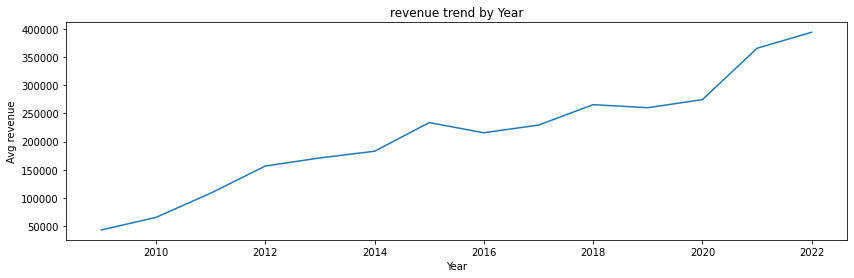

In [13]:
plt.figure(figsize=(14,4))
plt.plot(aaple['Year'],aaple['Revenue'],label="Aaple")
plt.xlabel('Year')
plt.ylabel('Avg revenue')
plt.title("revenue trend by Year")
plt.show()

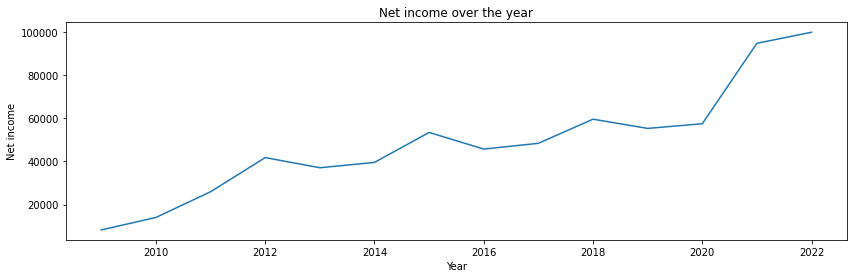

In [14]:
plt.figure(figsize=(14,4))
plt.plot(aaple['Year'],aaple['Net Income'],label="Aaple")
plt.xlabel('Year')
plt.ylabel('Net income')
plt.title("Net income over the year")
plt.show()

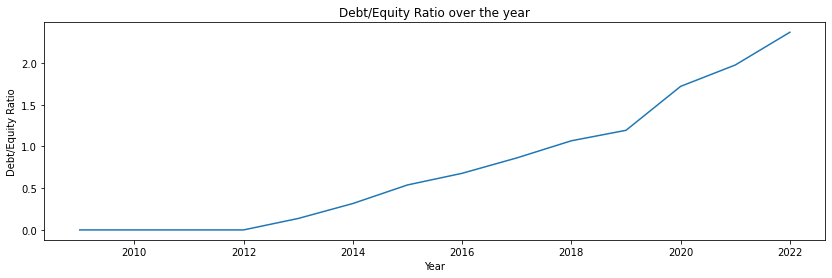

In [15]:
plt.figure(figsize=(14,4))
plt.plot(aaple['Year'],aaple['Debt/Equity Ratio'],label='Aaple')
plt.xlabel('Year')
plt.ylabel('Debt/Equity Ratio')
plt.title("Debt/Equity Ratio over the year")
plt.show()

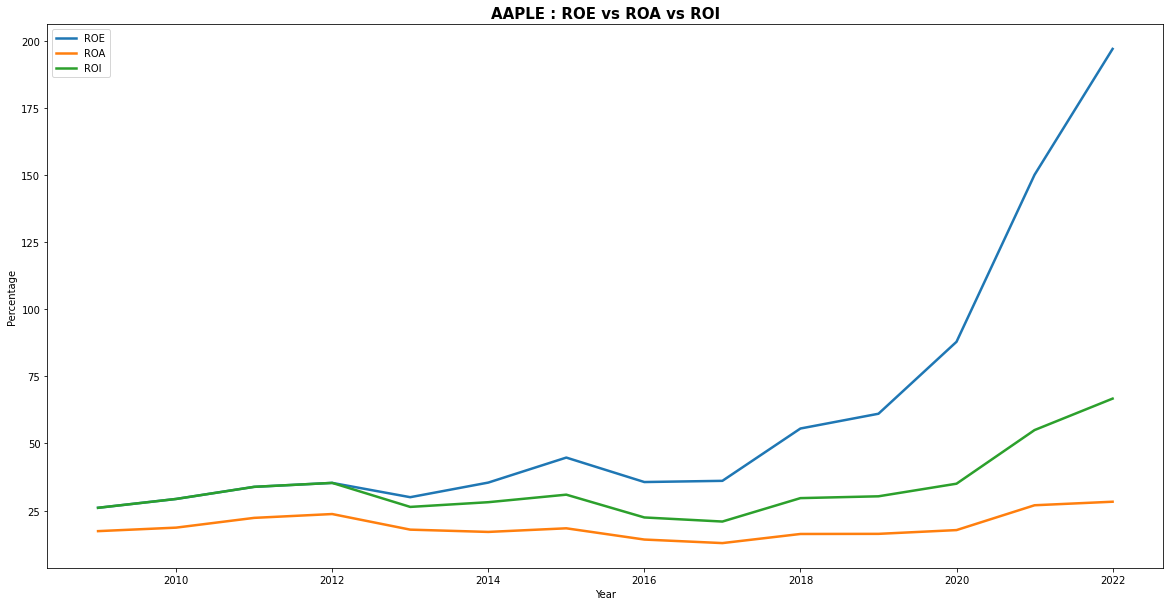

In [28]:

plt.figure(figsize=(20,10))
plt.plot(aaple['Year'],aaple['ROE'],linewidth=2.5,label='ROE')
plt.plot(aaple['Year'],aaple['ROA'],linewidth=2.5,label='ROA')
plt.plot(aaple['Year'],aaple['ROI'],linewidth=2.5,label='ROI')
plt.xlabel('Year')
plt.ylabel('Percentage')
plt.title('AAPLE : ROE vs ROA vs ROI',fontsize=15,fontweight='bold')
plt.legend()
plt.show()

In [ ]:
Revenue-Forecasting-Using-Linear-Regression-on-Financial-Statements